In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np   
import pandas as pd    

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

import lightgbm as lgb

In [2]:
from catboost import CatBoostRegressor

# 1. Analisis de datos

In [3]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [4]:
print('Train set shape:', train.shape)
print('Test set shape:', test.shape)

Train set shape: (300000, 26)
Test set shape: (200000, 25)


In [5]:
train.head()

,id,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,...,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,target
0,1,A,B,A,A,B,D,A,E,C,...,0.881122,0.421650,0.741413,0.895799,0.802461,0.724417,0.701915,0.877618,0.719903,6.994023
1,2,B,A,A,A,B,B,A,E,A,...,0.440011,0.346230,0.278495,0.593413,0.546056,0.613252,0.741289,0.326679,0.808464,8.071256
2,3,A,A,A,C,B,D,A,B,C,...,0.914155,0.369602,0.832564,0.865620,0.825251,0.264104,0.695561,0.869133,0.828352,5.760456
3,4,A,A,A,C,B,D,A,E,G,...,0.934138,0.578930,0.407313,0.868099,0.794402,0.494269,0.698125,0.809799,0.614766,7.806457
4,6,A,B,A,A,B,B,A,E,C,...,0.382600,0.705940,0.325193,0.440967,0.462146,0.724447,0.683073,0.343457,0.297743,6.868974


In [6]:
def missing_report(df, name):
    missing = df.isna().sum()
    percent = 100 * missing / len(df)
    
    report = (
        pd.DataFrame({
            'faltantes': missing,
            'porcentaje': percent
        })
        .query('faltantes > 0')
        .sort_values('porcentaje', ascending=False)
    )
    
    print(f'VALORES FALTANTES {name}:')
    print(report if not report.empty else 'No hay valores faltantes')
    print()

missing_report(train, 'TRAIN')
missing_report(test, 'TEST')

VALORES FALTANTES TRAIN:
No hay valores faltantes

VALORES FALTANTES TEST:
No hay valores faltantes



In [7]:
dup_train = train.duplicated().sum()
dup_test = test.duplicated().sum()
print(f'Duplicados en Train: {dup_train}, ({100*dup_train/len(train):.1f}%)\n')
print(f'Duplicados en Test: {dup_test}, ({100*dup_test/len(test):.1f}%)')

Duplicados en Train: 0, (0.0%)

Duplicados en Test: 0, (0.0%)


In [8]:
train.nunique()

id        300000
cat0           2
cat1           2
cat2           2
cat3           4
cat4           4
cat5           4
cat6           8
cat7           8
cat8           7
cat9          15
cont0     299830
cont1     299642
cont2     299707
cont3     299796
cont4     299736
cont5     299857
cont6     299875
cont7     299832
cont8     299765
cont9     299863
cont10    299894
cont11    299877
cont12    299824
cont13    299866
target    299648
dtype: int64

In [9]:
train['cat9'].value_counts(normalize=True) * 100

cat9
F    35.760333
I    16.688000
L    14.066667
H     8.253000
K     6.985000
A     4.469333
G     3.469667
M     3.279333
J     2.327000
O     2.057667
N     1.370667
B     1.145000
C     0.069667
D     0.034333
E     0.024333
Name: proportion, dtype: float64

In [10]:
train.describe()

,id,cont0,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,target
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,250018.576947,0.524634,0.506649,0.444115,0.446214,0.455471,0.508337,0.478345,0.455904,0.459321,0.526899,0.504943,0.529938,0.524549,0.503349,7.456260
std,144450.150010,0.204875,0.235269,0.200089,0.238669,0.200695,0.231612,0.192432,0.204493,0.220642,0.204025,0.201549,0.230860,0.220892,0.225218,0.887295
min,1.000000,-0.093505,-0.055105,-0.060274,0.134760,0.189216,-0.087247,0.043953,0.208703,0.004041,0.073040,0.059644,0.064161,-0.005600,0.158121,0.000000
25%,124772.500000,0.370451,0.352307,0.314121,0.214572,0.279853,0.338747,0.339896,0.278041,0.308655,0.361957,0.338898,0.316662,0.332143,0.291289,6.798341
50%,250002.500000,0.492208,0.615156,0.457271,0.377823,0.411351,0.441384,0.410090,0.360736,0.425801,0.488867,0.519855,0.558827,0.407365,0.433909,7.496503
75%,375226.500000,0.654793,0.688150,0.554835,0.719758,0.621808,0.709515,0.604246,0.639388,0.541525,0.752765,0.672809,0.720381,0.732431,0.730870,8.161166
max,499999.000000,1.052666,0.851746,1.017689,1.006469,0.994050,1.044433,1.093312,1.036541,1.014156,0.972091,1.029773,1.038049,0.961370,0.873579,10.309208


*Notas*

- No tenemos valores faltantes
- Empezaremos borrando el id
- Para las variables categorias usaremos One-Hot Encoding o Target Encoding
- Para el modelo podremos usar de base modelos de árboles (LightGBM, CatBoost)

*Perspectiva*

- Si usamos One-Hot tendremos muchas categorias la maxima en cat9 es de 15, lo cual aportaria mucho ruido.
- Usaremos el metodo Target Mean Encoding
- Usaremos KFold con validacion cruzada (CV)
- Realizaremos una funcion con suavisado en el Mean Encodig


# 2. Preprocesamiento Base

In [11]:
train = train.drop(columns=['id'])

In [12]:
cat_cols = [c for c in train.columns if c.startswith('cat')]
target_col = 'target'

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
class TargetMeanEncoderCV(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols, n_splits=5, alpha=10, random_state=42):
        self.cat_cols = cat_cols
        self.n_splits = n_splits
        self.alpha = alpha
        self.random_state = random_state

    def fit(self, X, y):
        X = X.copy()
        self.global_mean_ = y.mean()
        self.encoding_ = {}

        # ===== CV interno (solo para generar encoding sin leakage) =====
        kf = KFold(
            n_splits=self.n_splits,
            shuffle=True,
            random_state=self.random_state
        )

        for c in self.cat_cols:
            encoded = pd.Series(index=X.index, dtype=float)

            for tr_idx, val_idx in kf.split(X):
                X_tr = X.iloc[tr_idx]
                y_tr = y.iloc[tr_idx]

                stats = (
                    pd.concat([X_tr[c], y_tr], axis=1)
                    .groupby(c)[y_tr.name]
                    .agg(['mean', 'count'])
                )

                smooth = (
                    (stats['mean'] * stats['count']
                     + self.global_mean_ * self.alpha)
                    / (stats['count'] + self.alpha)
                )

                encoded.iloc[val_idx] = X.iloc[val_idx][c].map(smooth)

            # ===== Mapeo FINAL (para producción / transform) =====
            full_stats = (
                pd.concat([X[c], y], axis=1)
                .groupby(c)[y.name]
                .agg(['mean', 'count'])
            )

            self.encoding_[c] = (
                (full_stats['mean'] * full_stats['count']
                 + self.global_mean_ * self.alpha)
                / (full_stats['count'] + self.alpha)
            )

        return self

    def transform(self, X):
        X = X.copy()

        for c in self.cat_cols:
            X[f'{c}_mean'] = X[c].map(self.encoding_[c])
            X[f'{c}_mean'].fillna(self.global_mean_, inplace=True)

        return X.drop(columns=self.cat_cols)


In [14]:
pipe_lgb = Pipeline(steps=[
    ('mean_enc', TargetMeanEncoderCV(
        cat_cols=cat_cols,
        n_splits=5,
        alpha=10
    )),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [15]:
X = train.drop(columns='target')
y = train['target']

scores = cross_val_score(
    pipe_lgb,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    error_score='raise'  # útil si algo falla
)


In [16]:
enc = TargetMeanEncoderCV(cat_cols=cat_cols)
enc.fit(X, y)

type(enc.encoding_['cat0'])

pandas.core.series.Series

In [17]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

cv_results = cross_validate(
    pipe_lgb,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print(f"RMSE: {-cv_results['test_rmse'].mean():.5f}")
print(f"MAE : {-cv_results['test_mae'].mean():.5f}")
print(f"MSE : {-cv_results['test_mse'].mean():.5f}")
print(f"R2  : {cv_results['test_r2'].mean():.5f}")

RMSE: 0.84426
MAE : 0.70559
MSE : 0.71277
R2  : 0.09465


In [18]:
y.describe()


count    300000.000000
mean          7.456260
std           0.887295
min           0.000000
25%           6.798341
50%           7.496503
75%           8.161166
max          10.309208
Name: target, dtype: float64

In [19]:
y.var()

0.7872918932378952

Var(y)≈1−0.0950.71​≈0.785

# 3. Comparacion de modelo

*Nota*

- Comparemos con CatBoost

In [20]:
#Feature y target
X = train.drop(columns='target')
y = train['target']

In [21]:
X.head()

,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13
0,A,B,A,A,B,D,A,E,C,I,...,0.281421,0.881122,0.421650,0.741413,0.895799,0.802461,0.724417,0.701915,0.877618,0.719903
1,B,A,A,A,B,B,A,E,A,F,...,0.282354,0.440011,0.346230,0.278495,0.593413,0.546056,0.613252,0.741289,0.326679,0.808464
2,A,A,A,C,B,D,A,B,C,N,...,0.293756,0.914155,0.369602,0.832564,0.865620,0.825251,0.264104,0.695561,0.869133,0.828352
3,A,A,A,C,B,D,A,E,G,K,...,0.769785,0.934138,0.578930,0.407313,0.868099,0.794402,0.494269,0.698125,0.809799,0.614766
4,A,B,A,A,B,B,A,E,C,F,...,0.279105,0.382600,0.705940,0.325193,0.440967,0.462146,0.724447,0.683073,0.343457,0.297743


In [27]:
#Columnas categoricas
cat_features = [c for c in X.columns if c.startswith('cat')]
cat_idx = [X.columns.get_loc(c) for c in cat_features]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
rmse, mae, mse, r2 = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        cat_features=cat_features,
        early_stopping_rounds=100,
        verbose=False
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val)
    )

    preds = model.predict(X_val)

   



In [24]:
rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
mse.append(mean_squared_error(y_val, preds))
mae.append(mean_absolute_error(y_val, preds))
r2.append(r2_score(y_val, preds))

In [25]:
print(f"RMSE: {np.mean(rmse):.5f}")
print(f"MAE : {np.mean(mae):.5f}")
print(f"MSE : {np.mean(mse):.5f}")
print(f"R2  : {np.mean(r2):.5f}")

print(f"RMSE2: {np.mean(rmse):.4f} ± {np.std(rmse):.4f}")

RMSE: 0.84218
MAE : 0.70344
MSE : 0.70927
R2  : 0.09687
RMSE2: 0.8422 ± 0.0000


In [28]:
# Split hold out
from sklearn.model_selection import train_test_split

X = train.drop(columns='target')
y = train['target']

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

model.fit(
    X_tr,
    y_tr,
    cat_features=cat_idx
)

preds = model.predict(X_val)
residuals = y_val - preds

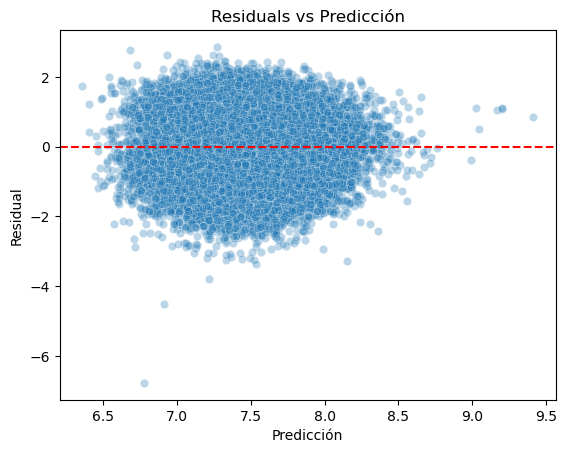

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=preds, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residual')
plt.title('Residuals vs Predicción')
plt.show()

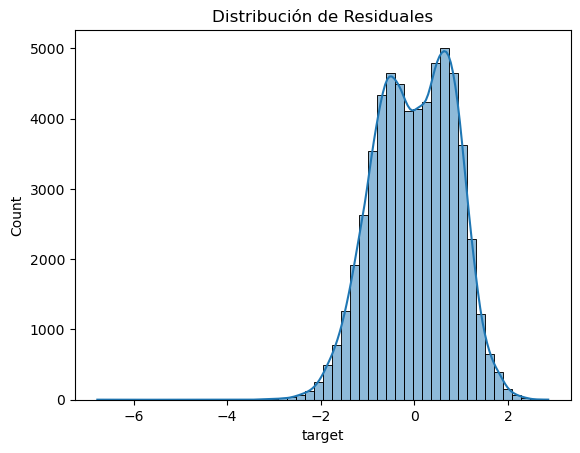

In [30]:
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribución de Residuales')
plt.show()

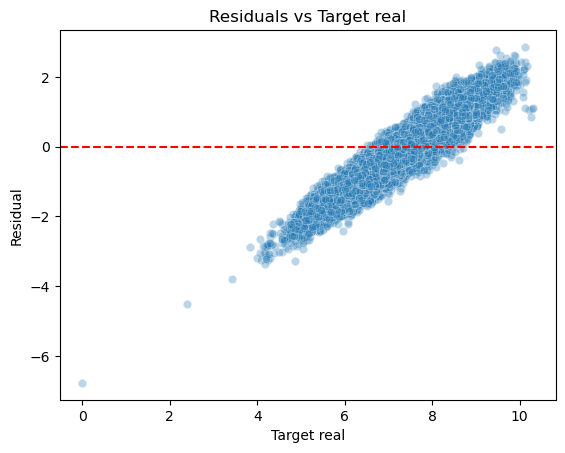

In [31]:
sns.scatterplot(x=y_val, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Target real')
plt.ylabel('Residual')
plt.title('Residuals vs Target real')
plt.show()

In [32]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

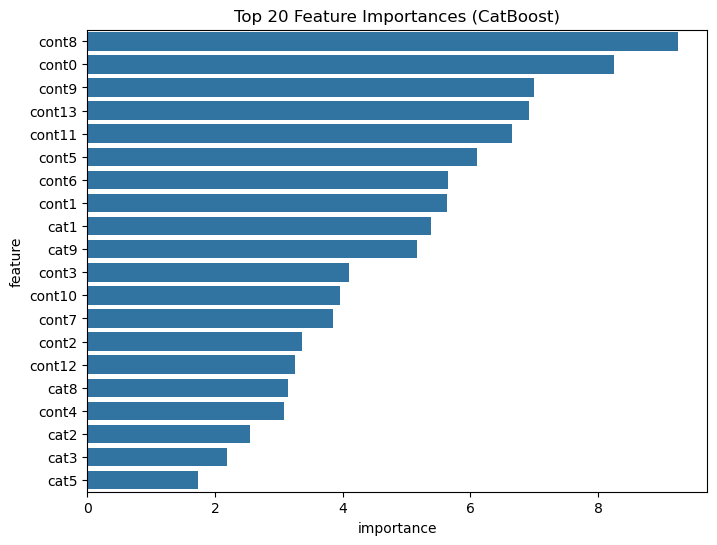

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp.head(20),
    x='importance',
    y='feature'
)
plt.title('Top 20 Feature Importances (CatBoost)')
plt.show()

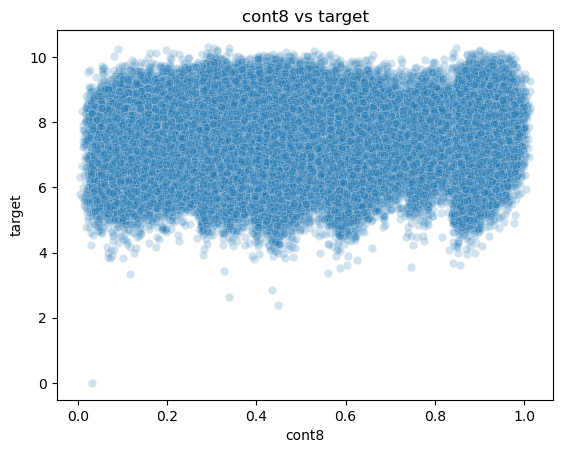

In [34]:
top_cont = feat_imp.query("feature.str.startswith('cont')", engine='python').iloc[0]['feature']

sns.scatterplot(x=train[top_cont], y=y, alpha=0.2)
plt.title(f'{top_cont} vs target')
plt.show()

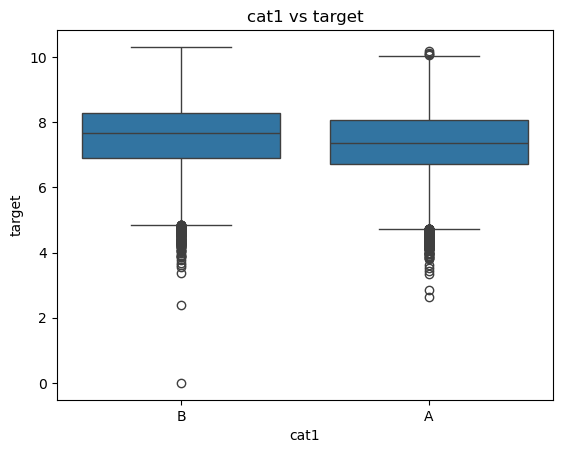

In [35]:
top_cat = feat_imp.query("feature.str.startswith('cat')", engine='python').iloc[0]['feature']

sns.boxplot(x=train[top_cat], y=y)
plt.title(f'{top_cat} vs target')
plt.show()

*Nota*
- Obtuvimos mejores resultados con CatBoost

# 4. Modelo Final

In [36]:
features = [c for c in train.columns if c not in ['id', 'target']]
cat_features = [c for c in features if c.startswith('cat')]

In [37]:
# Entrenar modelo final

X_train = train[features]
y_train = train['target']

model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    cat_features=cat_features,
    verbose=200
)

model.fit(X_train, y_train)

0:	learn: 0.8853745	total: 509ms	remaining: 12m 42s
200:	learn: 0.8449817	total: 1m 2s	remaining: 6m 44s
400:	learn: 0.8373334	total: 2m 8s	remaining: 5m 53s
600:	learn: 0.8321748	total: 3m 10s	remaining: 4m 44s
800:	learn: 0.8276040	total: 4m 11s	remaining: 3m 39s
1000:	learn: 0.8233063	total: 5m 13s	remaining: 2m 36s
1200:	learn: 0.8191802	total: 6m 15s	remaining: 1m 33s
1400:	learn: 0.8152930	total: 7m 16s	remaining: 30.9s
1499:	learn: 0.8131320	total: 7m 48s	remaining: 0us


Predecir sobre test

In [38]:
# Predecir
X_test = test[features]

test_preds = model.predict(X_test)

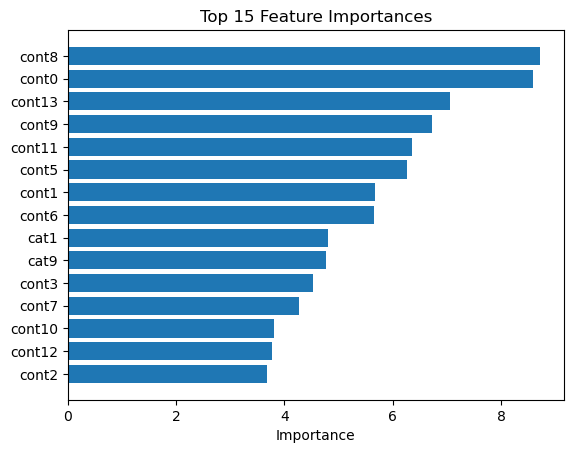

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtener importancias
importances = model.get_feature_importance()
feature_names = model.feature_names_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 15
plt.figure()
plt.barh(fi['feature'].head(15)[::-1], fi['importance'].head(15)[::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.show()


In [40]:
#Crear submission
submission = pd.DataFrame({
    'id': test['id'],
    'target': test_preds
})

submission.to_csv('submission.csv', index=False)

In [41]:
submission.head()

,id,target
0,0,7.680725
1,5,7.787566
2,15,7.629859
3,16,7.453001
4,17,7.252019


# 5. Mejorando el modelo

- Crear features derivadas (ratios, combinaciones)
- Analizar SHAP summary plot e importance
- Probar:
  
Target transformation

Ensembling

Feature selection guiada por SHAP

In [42]:
from catboost import Pool

cat_features = [c for c in X_train.columns if c.startswith('cat')]

train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)



In [43]:
shap_values = model.get_feature_importance(
    train_pool,
    type='ShapValues'
)


In [44]:
import pandas as pd

shap_df = pd.DataFrame(
    shap_values[:, :-1],  # quitamos el bias
    columns=X_train.columns
)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)


Podriamos analizar 'SHAP sumary plot' y continuamos haciendo un 'Feature Selection' guiada por SHAP

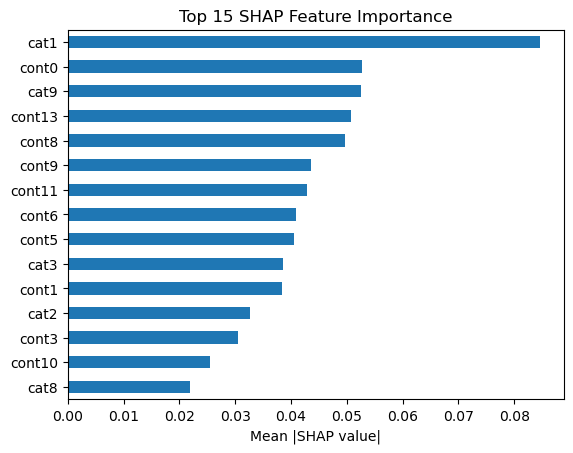

In [45]:
import matplotlib.pyplot as plt

plt.figure()
mean_abs_shap.head(15).iloc[::-1].plot(kind='barh')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 SHAP Feature Importance')
plt.show()


In [46]:
# Feature importance clásica
fi = model.get_feature_importance(prettified=True)
print(fi)

   Feature Id  Importances
0       cont8     8.725512
1       cont0     8.587330
2      cont13     7.060137
3       cont9     6.725268
4      cont11     6.352065
5       cont5     6.265590
6       cont1     5.665032
7       cont6     5.655592
8        cat1     4.804835
9        cat9     4.774220
10      cont3     4.534080
11      cont7     4.273869
12     cont10     3.812255
13     cont12     3.775878
14      cont2     3.674375
15      cont4     3.448112
16       cat8     2.567185
17       cat2     2.406232
18       cat3     2.115415
19       cat5     1.992134
20       cat0     0.964861
21       cat6     0.918668
22       cat7     0.667993
23       cat4     0.233363


In [47]:
# SHAP importance
shap_imp = mean_abs_shap.reset_index()
shap_imp.columns = ['feature', 'shap_importance']
print(shap_imp)

   feature  shap_importance
0     cat1         0.084650
1    cont0         0.052749
2     cat9         0.052453
3   cont13         0.050671
4    cont8         0.049655
5    cont9         0.043529
6   cont11         0.042851
7    cont6         0.040847
8    cont5         0.040546
9     cat3         0.038500
10   cont1         0.038399
11    cat2         0.032692
12   cont3         0.030423
13  cont10         0.025529
14    cat8         0.021854
15   cont7         0.019576
16  cont12         0.018530
17    cat0         0.016590
18   cont2         0.014805
19   cont4         0.013081
20    cat5         0.009522
21    cat6         0.009512
22    cat7         0.006292
23    cat4         0.001630


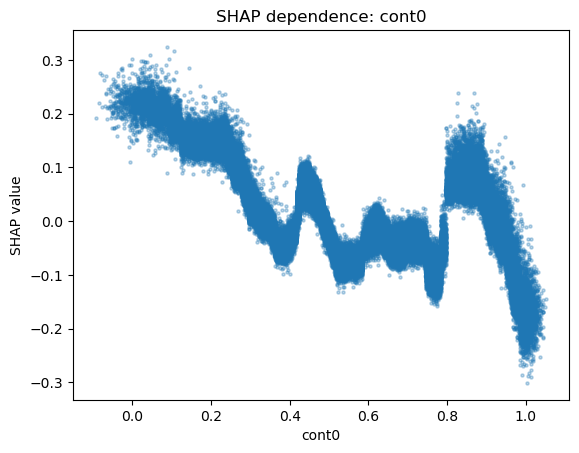

In [48]:
plt.figure()
plt.scatter(
    X_train['cont0'],
    shap_df['cont0'],
    s=5, alpha=0.3
)
plt.xlabel('cont0')
plt.ylabel('SHAP value')
plt.title('SHAP dependence: cont0')
plt.show()